<font size="+3">Visualize Real and Synthetic Data</font>

# Imports and Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.losses import (
    BinaryCrossentropy,
    MeanSquaredError,
    MeanAbsoluteError,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [3]:
sns.set_style("white")

In [4]:
path = Path("time_gan")
hdf_store = path / "TimeSeriesGAN.h5"

In [5]:
seq_len = 24
n_seq = 6

# Load Data

In [6]:
experiment = 0

In [7]:
def get_real_data():
    df = pd.read_hdf(hdf_store, "data/real").sort_index()

    # Preprocess the dataset:
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    data = []
    for i in range(len(df) - seq_len):
        data.append(scaled_data[i : i + seq_len])
    return data


real_data = get_real_data()

In [8]:
n = len(real_data)

In [9]:
np.asarray(real_data).shape

(4562, 24, 6)

In [10]:
synthetic_data = np.load(path / f"experiment_{experiment:02d}" / "generated_data.npy")
synthetic_data.shape

(4480, 24, 6)

In [11]:
real_data = real_data[: synthetic_data.shape[0]]

# Prepare Sample

In [12]:
sample_size = 250
idx = np.random.permutation(len(real_data))[:sample_size]

In [13]:
# Data preprocessing
real_sample = np.asarray(real_data)[idx]
synthetic_sample = np.asarray(synthetic_data)[idx]

In [14]:
real_sample_2d = real_sample.reshape(-1, seq_len)
synthetic_sample_2d = synthetic_sample.reshape(-1, seq_len)

In [15]:
real_sample_2d.shape, synthetic_sample_2d.shape

((1500, 24), (1500, 24))

# Visualization in 2D: A Qualitative Assessment of Diversity

## Run PCA

In [17]:
pca = PCA(n_components=2)
pca.fit(real_sample_2d)
pca_real = pd.DataFrame(pca.transform(real_sample_2d)).assign(Data="Real")
pca_synthetic = pd.DataFrame(pca.transform(synthetic_sample_2d)).assign(
    Data="Synthetic"
)
pca_result = pd.concat([pca_real, pca_synthetic], axis=0).rename(
    columns={0: "1st Component", 1: "2nd Component"}
)

## Run t-SNE

In [18]:
tsne_data = np.concatenate((real_sample_2d, synthetic_sample_2d), axis=0)

tsne = TSNE(n_components=2, verbose=1, perplexity=40)
tsne_result = tsne.fit_transform(tsne_data)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.001s...
[t-SNE] Computed neighbors for 3000 samples in 0.407s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 0.082200
[t-SNE] KL divergence after 250 iterations with early exaggeration: 53.485703
[t-SNE] KL divergence after 1000 iterations: 0.320873


In [19]:
tsne_result = pd.DataFrame(tsne_result, columns=["X", "Y"]).assign(Data="Real")
tsne_result.loc[sample_size * 6 :, "Data"] = "Synthetic"

## Plot Result

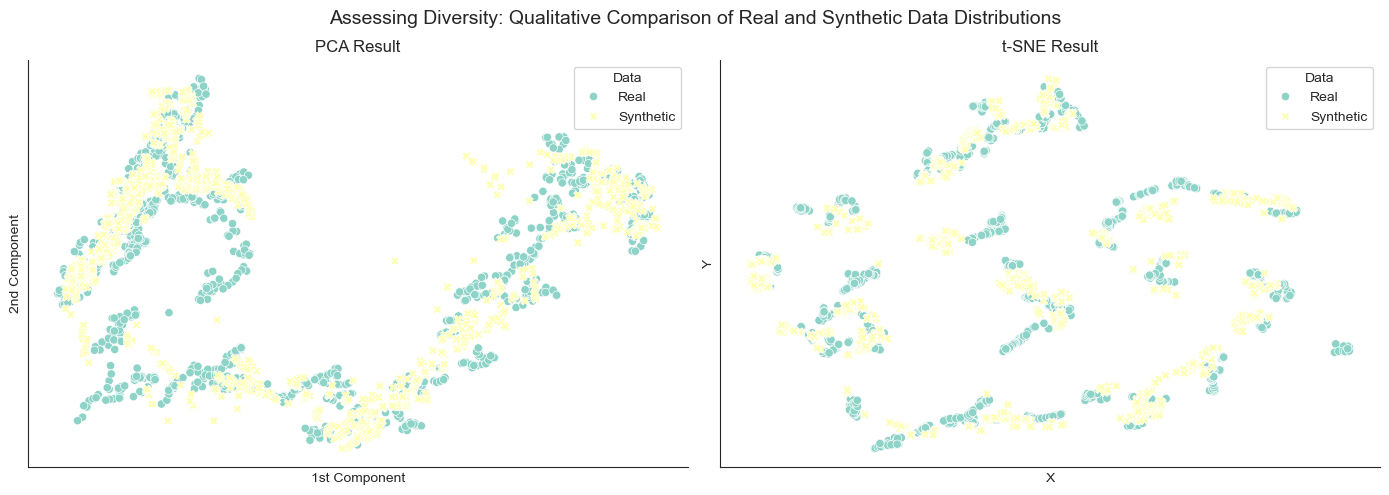

In [20]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

sns.scatterplot(
    x="1st Component",
    y="2nd Component",
    data=pca_result,
    hue="Data",
    style="Data",
    ax=axes[0],
)
sns.despine()
axes[0].set_title("PCA Result")


sns.scatterplot(x="X", y="Y", data=tsne_result, hue="Data", style="Data", ax=axes[1])
sns.despine()
for i in [0, 1]:
    axes[i].set_xticks([])
    axes[i].set_yticks([])

axes[1].set_title("t-SNE Result")
fig.suptitle(
    "Assessing Diversity: Qualitative Comparison of Real and Synthetic Data Distributions",
    fontsize=14,
)
fig.tight_layout()
fig.subplots_adjust(top=0.88);

# Time Series Classification: A quantitative Assessment of Fidelity

## Prepare Data

In [21]:
real_data = get_real_data()
real_data = np.array(real_data)[: len(synthetic_data)]
real_data.shape

(4480, 24, 6)

In [22]:
synthetic_data.shape

(4480, 24, 6)

In [23]:
n_series = real_data.shape[0]

In [24]:
idx = np.arange(n_series)

In [25]:
n_train = int(0.8 * n_series)
train_idx = idx[:n_train]
test_idx = idx[n_train:]

In [26]:
train_data = np.vstack((real_data[train_idx], synthetic_data[train_idx]))
test_data = np.vstack((real_data[test_idx], synthetic_data[test_idx]))

In [27]:
n_train, n_test = len(train_idx), len(test_idx)
train_labels = np.concatenate((np.ones(n_train), np.zeros(n_train)))
test_labels = np.concatenate((np.ones(n_test), np.zeros(n_test)))

## Create Classifier

In [28]:
ts_classifier = Sequential(
    [
        GRU(6, input_shape=(24, 6), name="GRU"),
        Dense(1, activation="sigmoid", name="OUT"),
    ],
    name="Time_Series_Classifier",
)

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
ts_classifier.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=[AUC(name="AUC"), "accuracy"]
)

In [30]:
ts_classifier.summary()

Model: "Time_Series_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GRU (GRU)                       │ (None, 6)              │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OUT (Dense)                     │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259 (1.01 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
result = ts_classifier.fit(
    x=train_data,
    y=train_labels,
    validation_data=(test_data, test_labels),
    epochs=250,
    batch_size=128,
    verbose=0,
)

In [32]:
ts_classifier.evaluate(x=test_data, y=test_labels)

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.1654 - accuracy: 0.2294 - loss: 4.9164     


[3.6229443550109863, 0.31403589248657227, 0.4162946343421936]

In [33]:
history = pd.DataFrame(result.history)
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AUC           250 non-null    float64
 1   accuracy      250 non-null    float64
 2   loss          250 non-null    float64
 3   val_AUC       250 non-null    float64
 4   val_accuracy  250 non-null    float64
 5   val_loss      250 non-null    float64
dtypes: float64(6)
memory usage: 11.8 KB


In [34]:
from matplotlib.ticker import FuncFormatter

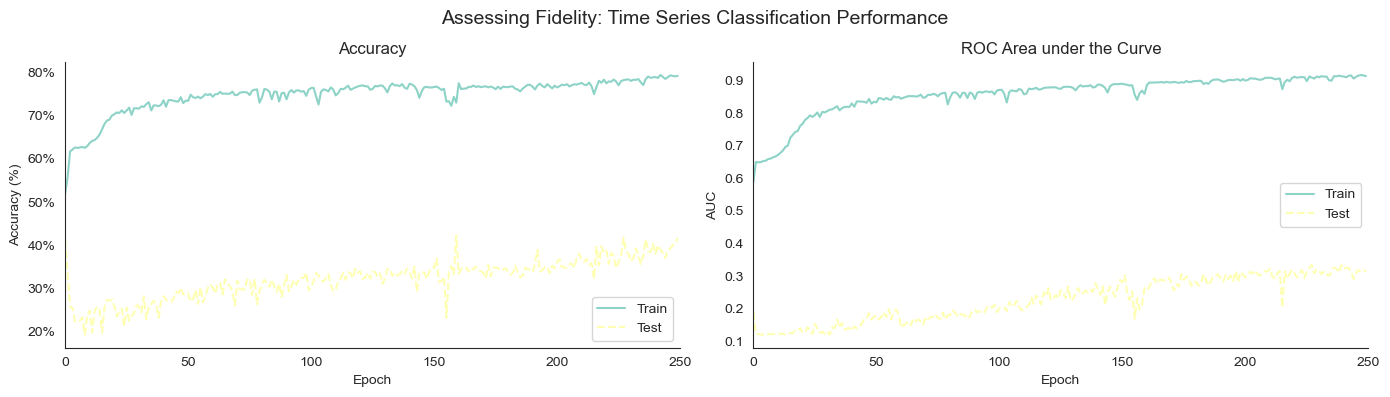

In [35]:
sns.set_style("white")
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
history[["AUC", "val_AUC"]].rename(columns={"AUC": "Train", "val_AUC": "Test"}).plot(
    ax=axes[1], title="ROC Area under the Curve", style=["-", "--"], xlim=(0, 250)
)
history[["accuracy", "val_accuracy"]].rename(
    columns={"accuracy": "Train", "val_accuracy": "Test"}
).plot(ax=axes[0], title="Accuracy", style=["-", "--"], xlim=(0, 250))
for i in [0, 1]:
    axes[i].set_xlabel("Epoch")

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))
axes[0].set_ylabel("Accuracy (%)")
axes[1].set_ylabel("AUC")
sns.despine()
fig.suptitle("Assessing Fidelity: Time Series Classification Performance", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85);

# Train on Synthetic, test on real: Assessing usefulness

In [36]:
real_data = get_real_data()
real_data = np.array(real_data)[: len(synthetic_data)]

In [37]:
real_data.shape, synthetic_data.shape

((4480, 24, 6), (4480, 24, 6))

In [38]:
real_train_data = real_data[train_idx, :23, :]
real_train_label = real_data[train_idx, -1, :]

real_test_data = real_data[test_idx, :23, :]
real_test_label = real_data[test_idx, -1, :]

In [39]:
(
    real_train_data.shape,
    real_train_label.shape,
    real_test_data.shape,
    real_test_label.shape,
)

((3584, 23, 6), (3584, 6), (896, 23, 6), (896, 6))

In [40]:
synthetic_train = synthetic_data[:, :23, :]
synthetic_label = synthetic_data[:, -1, :]

In [41]:
synthetic_train.shape, synthetic_label.shape

((4480, 23, 6), (4480, 6))

In [42]:
def get_model():
    model = Sequential([GRU(12, input_shape=(seq_len - 1, n_seq)), Dense(6)])

    model.compile(optimizer=Adam(), loss=MeanAbsoluteError(name="MAE"))
    return model

In [43]:
ts_regression = get_model()
synthetic_result = ts_regression.fit(
    x=synthetic_train,
    y=synthetic_label,
    validation_data=(real_test_data, real_test_label),
    epochs=100,
    batch_size=128,
    verbose=0,
)

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
ts_regression = get_model()
real_result = ts_regression.fit(
    x=real_train_data,
    y=real_train_label,
    validation_data=(real_test_data, real_test_label),
    epochs=100,
    batch_size=128,
    verbose=0,
)

In [45]:
synthetic_result = pd.DataFrame(synthetic_result.history).rename(
    columns={"loss": "Train", "val_loss": "Test"}
)
real_result = pd.DataFrame(real_result.history).rename(
    columns={"loss": "Train", "val_loss": "Test"}
)

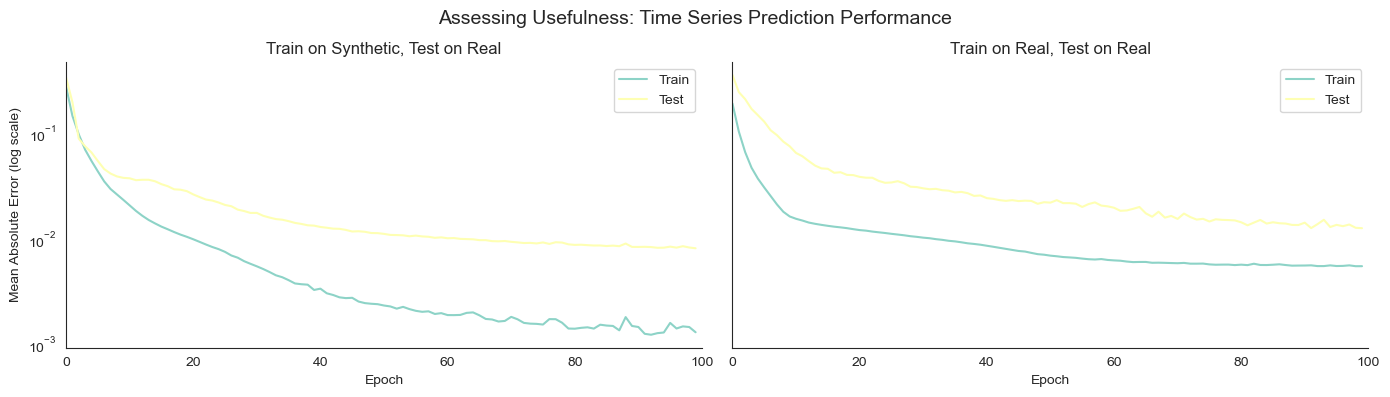

In [46]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4), sharey=True)
synthetic_result.plot(
    ax=axes[0], title="Train on Synthetic, Test on Real", logy=True, xlim=(0, 100)
)
real_result.plot(
    ax=axes[1], title="Train on Real, Test on Real", logy=True, xlim=(0, 100)
)
for i in [0, 1]:
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Mean Absolute Error (log scale)")

sns.despine()
fig.suptitle("Assessing Usefulness: Time Series Prediction Performance", fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85);